# EraMatch Behavioral AI — Notebook A: Modified Output Head

**Approach**: Take EfficientNet-B0 pretrained on ImageNet, remove its 1000-class classification head,
and replace it with a custom multi-label regression head that outputs 6 behavioral scores.

**Dataset**: RAF-DB (Fallback mode — with heuristic regression targets from emotion classes)

**Architecture**: EfficientNet-B0 backbone (frozen) → Custom regression head

**Citation**: Tan & Le, "EfficientNet: Rethinking Model Scaling for ConvNets", ICML 2019 — https://arxiv.org/abs/1905.11946

In [1]:
import os, json, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, Subset
from torchvision import transforms
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error
import seaborn as sns

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT = "/kaggle/working" if os.path.exists("/kaggle/working") else "./outputs"
os.makedirs(OUT, exist_ok=True)

print(f"Device: {DEVICE} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# Enable cudnn benchmark for better GPU performance
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.enabled = True

# Test if AMP (mixed precision) works on this GPU
# Some PyTorch/CUDA combos fail on autocast due to missing SM kernels
AMP_OK = False
if torch.cuda.is_available():
    try:
        with torch.cuda.amp.autocast():
            _test = torch.randn(1, 3, 8, 8).to(DEVICE)
            _conv = nn.Conv2d(3, 3, 3, padding=1).to(DEVICE)
            _ = _conv(_test)
        AMP_OK = True
        print("AMP autocast: OK")
    except RuntimeError as e:
        print(f"AMP autocast: FAILED ({e}). Training will use full fp32.")
        AMP_OK = False
else:
    AMP_OK = False

USE_AMP = AMP_OK
print(f"USE_AMP = {USE_AMP}")

# Install packages
!pip install optuna -q
!pip install timm -q --upgrade
import timm
import optuna
from optuna.visualization import matplotlib as optuna_vis

# CUDA diagnostics — check compute capability support
if torch.cuda.is_available():
    print(f"PyTorch: {torch.__version__} | CUDA: {torch.version.cuda}")
    print(f"GPU arch list: {torch.cuda.get_arch_list()}")
    gpu_cc = torch.cuda.get_device_capability(0)
    print(f"GPU compute capability: sm_{gpu_cc[0]}{gpu_cc[1]}")
    if f"sm_{gpu_cc[0]}{gpu_cc[1]}" not in torch.cuda.get_arch_list():
        print(f"WARNING: GPU compute capability sm_{gpu_cc[0]}{gpu_cc[1]} NOT in PyTorch arch list!")
        print("This will cause cudaErrorNoKernelImageForDevice. Trying fix...")
print(f"timm version: {timm.__version__}")

Device: cuda | GPU: Tesla T4
AMP autocast: OK
USE_AMP = True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 71.2 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128 | CUDA: 12.8
GPU arch list: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
GPU compute capability: sm_75
timm version: 1.0.27


## Dataset Discovery

In [2]:
# --- Dataset Discovery ---
# Known RAF-DB paths on Kaggle

train_dir = None
test_dir = None

for candidate in [
    '/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train',
    '/kaggle/input/raf-db-dataset/DATASET/train',
    '/kaggle/input/raf-db-dataset/train',
]:
    if os.path.isdir(candidate) and any(str(i) in os.listdir(candidate) for i in range(1, 8)):
        train_dir = candidate
        break

if train_dir is None:
    for root, dirs, _ in os.walk('/kaggle/input/'):
        if all(str(i) in dirs for i in range(1, 8)):
            train_dir = root
            break

if train_dir is None:
    raise FileNotFoundError(
        "RAF-DB dataset not found. Add it via Kaggle UI -> Add Data -> "
        "search 'raf-db-dataset' by shuvoalok. Also make sure Internet is ON in Settings."
    )

data_root = os.path.dirname(os.path.dirname(train_dir)) if 'DATASET' in train_dir else os.path.dirname(train_dir)

# Locate official test split (DATASET/test/ with subfolders 1-7)
for candidate in [
    os.path.join(data_root, 'DATASET', 'test'),
    os.path.join(data_root, 'test'),
]:
    if os.path.isdir(candidate) and any(str(i) in os.listdir(candidate) for i in range(1, 8)):
        test_dir = candidate
        break

print(f'Dataset root: {data_root}')
print(f'Train directory: {train_dir}')
if test_dir:
    print(f'Test directory: {test_dir}')
    test_counts = {i: len(os.listdir(os.path.join(test_dir, str(i)))) for i in range(1, 8) if os.path.isdir(os.path.join(test_dir, str(i)))}
    print(f'Test images per class: {test_counts}')
else:
    print('No official test split found — will use random 10% split from training data.')
for sf in sorted(os.listdir(train_dir))[:3]:
    sf_path = os.path.join(train_dir, sf)
    if os.path.isdir(sf_path):
        print(f'  Train {sf}/: {len(os.listdir(sf_path))} files')

Dataset root: /kaggle/input/datasets/shuvoalok/raf-db-dataset
Train directory: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train
Test directory: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test
Test images per class: {1: 329, 2: 74, 3: 160, 4: 1185, 5: 478, 6: 162, 7: 680}
  Train 1/: 1290 files
  Train 2/: 281 files
  Train 3/: 717 files


In [3]:
class RAFDBDataset(Dataset):
    """RAF-DB dataset with heuristic regression targets for behavioral analysis.
    
    Supports three modes:
    1. Folder mode (integer folders 1-7): RAF-DB default
    2. Folder mode (string folders like 'angry', 'happy'): FER2013 style
    3. CSV mode: loads images + labels from a CSV file
    
    Fallback mode: emotion classes -> simulated regression scores.
    """
    
    # 1-indexed mapping (RAF-DB uses folders 1-7)
    CLASS_TO_SCORES = {
        1: {"confidence": 0.5, "anxiety": 0.3, "engagement": 0.6, "stability": 0.6, "composed": 0.5, "interview": 0.50},  # Surprise
        2: {"confidence": 0.2, "anxiety": 0.7, "engagement": 0.3, "stability": 0.3, "composed": 0.2, "interview": 0.25},  # Fear
        3: {"confidence": 0.2, "anxiety": 0.3, "engagement": 0.2, "stability": 0.4, "composed": 0.3, "interview": 0.20},  # Disgust
        4: {"confidence": 0.8, "anxiety": 0.1, "engagement": 0.7, "stability": 0.8, "composed": 0.7, "interview": 0.75},  # Happy
        5: {"confidence": 0.3, "anxiety": 0.4, "engagement": 0.2, "stability": 0.4, "composed": 0.3, "interview": 0.30},  # Sad
        6: {"confidence": 0.4, "anxiety": 0.5, "engagement": 0.5, "stability": 0.3, "composed": 0.2, "interview": 0.35},  # Angry
        7: {"confidence": 0.6, "anxiety": 0.1, "engagement": 0.4, "stability": 0.9, "composed": 0.8, "interview": 0.60},  # Neutral
    }
    
    # FER2013 string folder names -> RAF-DB class index
    FER2013_LABEL_MAP = {
        'angry': 6, 'disgust': 3, 'fear': 2, 'happy': 4,
        'sad': 5, 'surprise': 1, 'neutral': 7,
        'disgusted': 3, 'fearful': 2, 'surprised': 1,
    }
    
    SCORE_NAMES = ["confidence", "anxiety", "engagement", "stability", "composed", "interview"]
    
    def __init__(self, root_dir, transform=None, noise_std=0.03, csv_path=None):
        self.root_dir = root_dir
        self.transform = transform
        self.noise_std = noise_std
        self.samples = []  # list of (img_path, class_idx)
        
        if csv_path is not None:
            # CSV mode: load from test_labels.csv
            import pandas as pd
            df = pd.read_csv(csv_path)
            img_col = 'image' if 'image' in df.columns else df.columns[0]
            lbl_col = 'label' if 'label' in df.columns else df.columns[-1]
            for _, row in df.iterrows():
                img_name = str(row[img_col])
                class_idx = int(row[lbl_col])
                img_path = os.path.join(root_dir, str(class_idx), img_name)
                if not os.path.exists(img_path):
                    img_path = os.path.join(root_dir, img_name)
                if os.path.exists(img_path):
                    self.samples.append((img_path, class_idx))
            print(f"Loaded {len(self.samples)} images from CSV ({csv_path})")
        else:
            # Folder mode: try integer folders (1-7) first, then string folders
            found_integer = any(os.path.isdir(os.path.join(root_dir, str(i))) for i in range(1, 8))
            if found_integer:
                for class_idx in range(1, 8):
                    class_dir = os.path.join(root_dir, str(class_idx))
                    if os.path.isdir(class_dir):
                        for img_name in os.listdir(class_dir):
                            img_path = os.path.join(class_dir, img_name)
                            if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                                self.samples.append((img_path, class_idx))
            else:
                # String folder names (FER2013 style: angry, happy, etc.)
                for folder_name in os.listdir(root_dir):
                    folder_path = os.path.join(root_dir, folder_name)
                    if not os.path.isdir(folder_path):
                        continue
                    class_idx = self.FER2013_LABEL_MAP.get(folder_name.lower())
                    if class_idx is None:
                        continue
                    for img_name in os.listdir(folder_path):
                        img_path = os.path.join(folder_path, img_name)
                        if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                            self.samples.append((img_path, class_idx))
            print(f"Loaded {len(self.samples)} images from {root_dir}")
        
        if len(self.samples) == 0:
            raise ValueError(f"No images found. root_dir={root_dir}, csv_path={csv_path}. Check paths.")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, class_idx = self.samples[idx]
        
        from PIL import Image
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Warning: Failed to load {img_path}: {e}")
            return self.__getitem__((idx + 1) % len(self))
        
        # Get base scores from class mapping
        base_scores = self.CLASS_TO_SCORES[class_idx].copy()
        target = np.array([base_scores[k] for k in SCORE_NAMES], dtype=np.float32)
        
        # Add Gaussian noise to prevent memorization of 7 discrete points
        if self.noise_std > 0:
            noise = np.random.normal(0, self.noise_std, 6).astype(np.float32)
            target = np.clip(target + noise, 0.0, 1.0)
        
        if self.transform:
            image = self.transform(image)
        
        return image, target, class_idx

In [4]:
# --- Transforms ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Class Weights & WeightedRandomSampler ---
def compute_class_weights(dataset):
    """Compute per-sample weights for WeightedRandomSampler to handle imbalance."""
    from collections import Counter
    # dataset.samples stores (img_path, class_idx) tuples — class is at index [1]
    class_counts = Counter(sample[1] for sample in dataset.samples)
    total = len(dataset)
    class_weights = {cls: total / (len(class_counts) * count) for cls, count in class_counts.items()}
    sample_weights = [class_weights[s[1]] for s in dataset.samples]
    return sample_weights, class_counts

SCORE_NAMES = ["confidence", "anxiety", "engagement", "stability", "composed", "interview"]
print("Transforms and label mapping ready.")

Transforms and label mapping ready.


## Model Architecture

**EfficientNet-B0** backbone (pretrained on ImageNet-1k, frozen for Phase 1) -> **Custom Multi-Label Regression Head**

- Backbone: `efficientnet_b0.ra_in1k` from timm (1280-dim output)
- Head: Dropout(0.4) -> Linear(1280, 256) -> ReLU -> Dropout(0.3) -> Linear(256, 6) -> Sigmoid
- Output: 6 behavioral scores in [0, 1]

Reference: Tan & Le, "EfficientNet: Rethinking Model Scaling for ConvNets", ICML 2019 -- https://arxiv.org/abs/1905.11946

In [5]:
# --- Model Definition ---
class BehavioralHead(nn.Module):
    """Custom multi-label regression head for behavioral analysis."""
    def __init__(self, in_features=1280, hidden_dim=256, num_outputs=6, dropout1=0.4, dropout2=0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Dropout(dropout1),
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout2),
            nn.Linear(hidden_dim, num_outputs),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.head(x)


class BehavioralModel(nn.Module):
    """EfficientNet-B0 backbone with custom behavioral regression head."""
    def __init__(self, dropout1=0.4, dropout2=0.3):
        super().__init__()
        # no_jit=True disables JIT-scripted Swish/SiLU activations that cause
        # cudaErrorNoKernelImageForDevice on T4 (sm_75) GPUs. Uses native nn.SiLU instead.
        self.backbone = timm.create_model('efficientnet_b0.ra_in1k', pretrained=True, num_classes=0, no_jit=True)
        self.classifier = BehavioralHead(in_features=1280, hidden_dim=256, num_outputs=6,
                                          dropout1=dropout1, dropout2=dropout2)
    
    def forward(self, x):
        features = self.backbone(x)  # (batch, 1280)
        return self.classifier(features)  # (batch, 6)


model = BehavioralModel(dropout1=0.4, dropout2=0.3).to(DEVICE)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Backbone blocks: {len(model.backbone.blocks)}")

# Verify forward pass
model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
    out = model(dummy)
    print(f"Forward pass test: input={dummy.shape}, output={out.shape}")
    print(f"Output range: [{out.min().item():.3f}, {out.max().item():.3f}]")
model.train()

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Total parameters: 4,337,026
Trainable parameters: 4,337,026
Backbone blocks: 7
Forward pass test: input=torch.Size([2, 3, 224, 224]), output=torch.Size([2, 6])
Output range: [0.492, 0.514]


BehavioralModel(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw

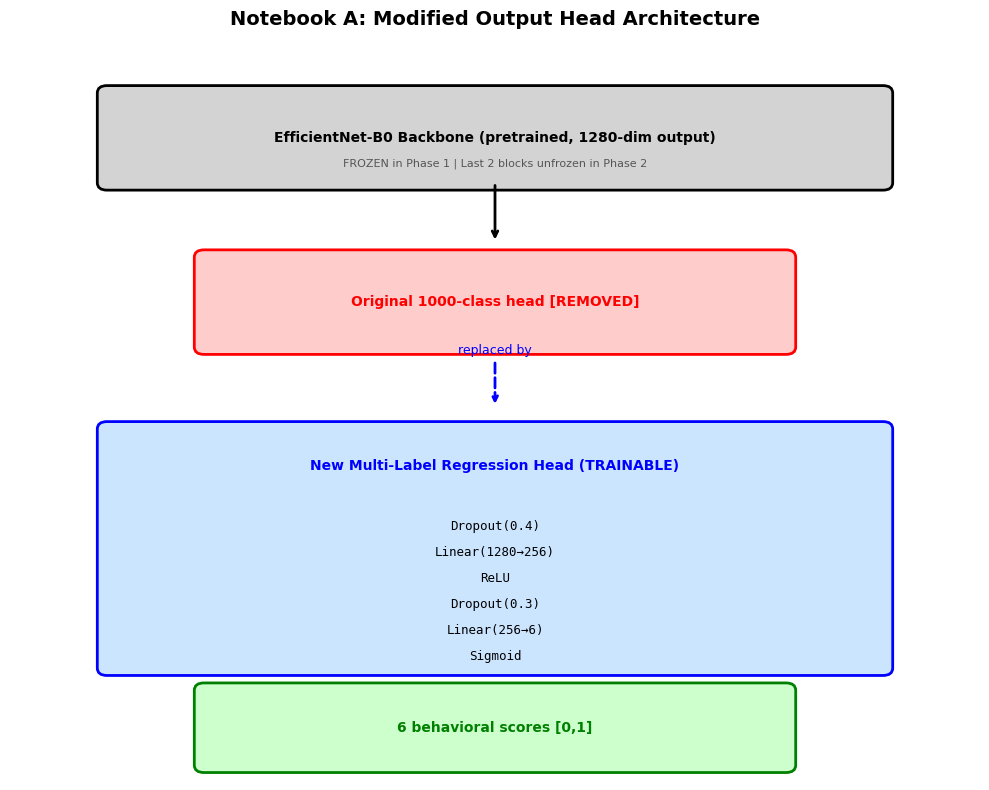

Architecture diagram saved.


In [6]:
# --- Architecture Diagram ---
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Notebook A: Modified Output Head Architecture', fontsize=14, fontweight='bold')

# Box 1: Backbone (grey, frozen)
backbone_box = mpatches.FancyBboxPatch((1, 8), 8, 1.2, boxstyle="round,pad=0.1",
                                         facecolor='#d3d3d3', edgecolor='black', linewidth=2)
ax.add_patch(backbone_box)
ax.text(5, 8.6, 'EfficientNet-B0 Backbone (pretrained, 1280-dim output)', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(5, 8.25, 'FROZEN in Phase 1 | Last 2 blocks unfrozen in Phase 2', ha='center', va='center', fontsize=8, color='#555555')

# Arrow
ax.annotate('', xy=(5, 7.2), xytext=(5, 8.0),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Box 2: Removed head (red)
removed_box = mpatches.FancyBboxPatch((2, 5.8), 6, 1.2, boxstyle="round,pad=0.1",
                                        facecolor='#ffcccc', edgecolor='red', linewidth=2)
ax.add_patch(removed_box)
ax.text(5, 6.4, 'Original 1000-class head [REMOVED]', ha='center', va='center', fontsize=10, fontweight='bold', color='red')

# Dashed arrow "replaced by"
ax.annotate('replaced by', xy=(5, 5.0), xytext=(5, 5.7),
            arrowprops=dict(arrowstyle='->', lw=2, color='blue', linestyle='dashed'),
            fontsize=9, ha='center', color='blue')

# Box 3: New head (blue, trainable)
head_box = mpatches.FancyBboxPatch((1, 1.5), 8, 3.2, boxstyle="round,pad=0.1",
                                    facecolor='#cce5ff', edgecolor='blue', linewidth=2)
ax.add_patch(head_box)
ax.text(5, 4.2, 'New Multi-Label Regression Head (TRAINABLE)', ha='center', va='center', fontsize=10, fontweight='bold', color='blue')

# Sub-boxes inside head
sub_steps = ['Dropout(0.4)', 'Linear(1280\u2192256)', 'ReLU', 'Dropout(0.3)', 'Linear(256\u21926)', 'Sigmoid']
for i, step in enumerate(sub_steps):
    y = 3.4 - i * 0.35
    ax.text(5, y, step, ha='center', va='center', fontsize=9, fontfamily='monospace')

# Output box (green)
output_box = mpatches.FancyBboxPatch((2, 0.2), 6, 1.0, boxstyle="round,pad=0.1",
                                       facecolor='#ccffcc', edgecolor='green', linewidth=2)
ax.add_patch(output_box)
ax.text(5, 0.7, '6 behavioral scores [0,1]', ha='center', va='center', fontsize=10, fontweight='bold', color='green')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'model_architecture.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Architecture diagram saved.')

In [7]:
def scores_to_behavioral_tags(scores: dict) -> dict:
    """
    Convert raw model scores to EraMatch behavioral tag format.
    Handles three input formats:
    1. First Impressions V2 personality traits (extraversion, agreeableness, etc.)
    2. Emotion classifier probabilities (happy, sad, angry, etc.)
    3. RAF-DB regression outputs (confidence, anxiety, engagement, stability, composed)
    """
    if "extraversion" in scores and "neuroticism" in scores:
        # First Impressions V2 path
        confidence = scores["extraversion"] * 0.5 + (1 - scores["neuroticism"]) * 0.5
        anxiety = scores["neuroticism"] * 0.7 + (1 - scores.get("interview", 0.5)) * 0.3
        engagement = scores["extraversion"] * 0.4 + scores["openness"] * 0.4 + scores.get("interview", 0.5) * 0.2
        stability = scores["conscientiousness"] * 0.5 + scores["agreeableness"] * 0.3 + (1 - scores["neuroticism"]) * 0.2
        composed = scores.get("interview", 0.5) * 0.6 + scores["agreeableness"] * 0.4
        emotion_map = {k: v for k, v in scores.items() if k not in
                      ["extraversion", "agreeableness", "conscientiousness", "neuroticism", "openness", "interview"]}
    elif "confidence" in scores and "anxiety" in scores:
        # RAF-DB regression path -- outputs are already behavioral scores
        confidence = max(0.0, min(1.0, scores["confidence"]))
        anxiety = max(0.0, min(1.0, scores["anxiety"]))
        engagement = max(0.0, min(1.0, scores["engagement"]))
        stability = max(0.0, min(1.0, scores["stability"]))
        composed = max(0.0, min(1.0, scores["composed"]))
        emotion_map = {k: v for k, v in scores.items() if k not in
                      ["confidence", "anxiety", "engagement", "stability", "composed", "interview"]}
    else:
        # Emotion classifier path
        confidence = scores.get("happy", 0) * 0.4 + scores.get("neutral", 0) * 0.3 + scores.get("calm", 0) * 0.3
        anxiety = scores.get("fearful", 0) * 0.6 + scores.get("sad", 0) * 0.2 + scores.get("angry", 0) * 0.2
        engagement = scores.get("happy", 0) * 0.5 + scores.get("surprised", 0) * 0.3 + scores.get("angry", 0) * 0.2
        stability = 1.0 - scores.get("fearful", 0) - scores.get("angry", 0) * 0.5
        composed = scores.get("neutral", 0) + scores.get("calm", 0) + scores.get("happy", 0) * 0.3
        emotion_map = {k: v for k, v in scores.items() if k not in
                      ["extraversion", "agreeableness", "conscientiousness", "neuroticism", "openness", "interview"]}

    # Clamp all
    confidence = max(0.0, min(1.0, confidence))
    anxiety = max(0.0, min(1.0, anxiety))
    engagement = max(0.0, min(1.0, engagement))
    stability = max(0.0, min(1.0, stability))
    composed = max(0.0, min(1.0, composed))

    # Dominant emotion
    if emotion_map:
        dominant = max(emotion_map, key=emotion_map.get)
    else:
        if confidence > 0.7 and anxiety < 0.3:
            dominant = "confident"
        elif anxiety > 0.5:
            dominant = "anxious"
        elif engagement > 0.6:
            dominant = "engaged"
        elif stability > 0.6:
            dominant = "calm"
        else:
            dominant = "neutral"

    def summarize(conf, anx, eng):
        parts = []
        parts.append("Candidate shows strong confidence" if conf > 0.6 else
                     "Candidate appears uncertain" if conf < 0.35 else
                     "Candidate shows moderate confidence")
        if anx > 0.5:   parts.append("with notable anxiety signals")
        elif eng > 0.6: parts.append("with high engagement throughout")
        return ". ".join(parts) + "."

    return {
        "confidence_level":    round(confidence, 3),
        "anxiety_signal":      round(anxiety, 3),
        "engagement_level":    round(engagement, 3),
        "emotional_stability": round(stability, 3),
        "dominant_emotion":    dominant,
        "engagement_trend":    "flat",   # overridden in NB-B and NB-C with temporal data
        "composed_ratio":      round(composed, 3),
        "behavioral_summary":  summarize(confidence, anxiety, engagement),
    }

# Test the regression path
test_scores = {"confidence": 0.72, "anxiety": 0.15, "engagement": 0.68, "stability": 0.81, "composed": 0.74}
test_tags = scores_to_behavioral_tags(test_scores)
print("Test behavioral tags (regression path):")
print(json.dumps(test_tags, indent=2))

Test behavioral tags (regression path):
{
  "confidence_level": 0.72,
  "anxiety_signal": 0.15,
  "engagement_level": 0.68,
  "emotional_stability": 0.81,
  "dominant_emotion": "confident",
  "engagement_trend": "flat",
  "composed_ratio": 0.74,
  "behavioral_summary": "Candidate shows strong confidence. with high engagement throughout."
}


In [8]:
# --- Dataset Splits & DataLoaders ---
# Train dataset with augmentation + noise, val/test datasets without noise
train_dataset = RAFDBDataset(train_dir, transform=train_transforms, noise_std=0.03)
val_test_dataset = RAFDBDataset(train_dir, transform=val_transforms, noise_std=0.0)

if test_dir is not None:
    # Official test split: use RAF-DB's held-out test set
    test_dataset = RAFDBDataset(test_dir, transform=val_transforms, noise_std=0.0)
    # Val split: 10% of training data (stratified)
    total_size = len(train_dataset)
    val_size = int(0.1 * total_size)
    indices = list(range(total_size))
    random.shuffle(indices)
    val_idx = indices[:val_size]
    train_idx = indices[val_size:]  # rest for training
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(val_test_dataset, val_idx)
    print(f'Using official RAF-DB test split ({len(test_dataset)} images)')
else:
    # Fallback: random 80/10/10 split from training data
    total_size = len(train_dataset)
    train_size = int(0.8 * total_size)
    val_size = int(0.1 * total_size)
    indices = list(range(total_size))
    random.shuffle(indices)
    train_idx = indices[:train_size]
    val_idx = indices[train_size:train_size + val_size]
    test_idx = indices[train_size + val_size:]
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(val_test_dataset, val_idx)
    test_dataset = Subset(val_test_dataset, test_idx)
    print(f'Using random 80/10/10 split (no official test set found)')

# WeightedRandomSampler for training (handle class imbalance)
sample_weights, class_counts = compute_class_weights(train_dataset)
train_weights = [sample_weights[i] for i in train_idx]
sampler = WeightedRandomSampler(train_weights, num_samples=len(train_weights), replacement=True)

# DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_dataset)}")
print(f"Class distribution: {dict(sorted(class_counts.items()))}")

# VRAM check
if torch.cuda.is_available():
    print(f"GPU memory available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Loaded 12271 images from /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train
Loaded 12271 images from /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train
Loaded 3068 images from /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test
Using official RAF-DB test split (3068 images)
Train: 11044 | Val: 1227 | Test: 3068
Class distribution: {1: 1290, 2: 281, 3: 717, 4: 4772, 5: 1982, 6: 705, 7: 2524}
GPU memory available: 15.6 GB


## Hyperparameter Optimization (Optuna)

Before full training, we use **Optuna** (Akiba et al., KDD 2019) to find the best hyperparameters:
- **Search space**: learning rate (1e-5 to 1e-2, log), weight_decay (1e-6 to 1e-3, log), dropout1 (0.2-0.5), dropout2 (0.1-0.4)
- **Strategy**: 20 trials with TPE sampler, MedianPruner (stops unpromising trials early)
- **Objective**: Train head-only for 8 epochs, minimize validation MAE
- After HPO, the best params are used for full 40-epoch training (Phase 1 + Phase 2)

In [9]:
# --- Optuna Hyperparameter Optimization ---
# 20 trials, each trains the head-only for 8 epochs. MedianPruner stops bad trials early.
# Reference: Akiba et al., "Optuna: A Next-generation Hyperparameter Optimization Framework", KDD 2019

import optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
)

def create_model_with_params(dropout1, dropout2):
    """Create a fresh model with given dropout params, backbone frozen."""
    m = BehavioralModel(dropout1=dropout1, dropout2=dropout2).to(DEVICE)
    for param in m.backbone.parameters():
        param.requires_grad = False
    for param in m.classifier.parameters():
        param.requires_grad = True
    return m

def hpo_objective(trial):
    """Optuna objective: train head-only for 8 epochs, return best val_mae."""
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    dropout1 = trial.suggest_float('dropout1', 0.2, 0.5)
    dropout2 = trial.suggest_float('dropout2', 0.1, 0.4)
    
    model_hpo = create_model_with_params(dropout1, dropout2)
    optimizer_hpo = optim.AdamW(model_hpo.classifier.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler_hpo = optim.lr_scheduler.CosineAnnealingLR(optimizer_hpo, T_max=8, eta_min=1e-7)
    criterion_hpo = nn.MSELoss()
    scaler_hpo = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    
    best_val_mae = float('inf')
    for epoch in range(1, 9):  # 8 epochs per trial
        model_hpo.train()
        for images, targets, _ in train_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            optimizer_hpo.zero_grad()
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = model_hpo(images)
                loss = criterion_hpo(outputs, targets)
            scaler_hpo.scale(loss).backward()
            scaler_hpo.step(optimizer_hpo)
            scaler_hpo.update()
        scheduler_hpo.step()
        
        # Validation
        model_hpo.eval()
        val_mae_total = torch.zeros(6).to(DEVICE)
        with torch.no_grad():
            for images, targets, _ in val_loader:
                images, targets = images.to(DEVICE), targets.to(DEVICE)
                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    outputs = model_hpo(images)
                val_mae_total += torch.abs(outputs - targets).sum(dim=0)
        val_mae = (val_mae_total / len(val_subset)).mean().item()
        best_val_mae = min(best_val_mae, val_mae)
        
        # Report to pruner
        trial.report(val_mae, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    del model_hpo
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    return best_val_mae

print("Starting Optuna HPO (20 trials, ~8 epochs each)...")
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)
study.optimize(hpo_objective, n_trials=20, show_progress_bar=True)

print(f"\n{'='*50}")
print(f"Best HPO trial: {study.best_trial.number}")
print(f"Best val_mae: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")
print(f"{'='*50}")

best_hpo_params = study.best_params.copy()


[I 2026-05-11 16:54:22,421] A new study created in memory with name: no-name-183a7fc4-c979-41da-98a4-93f33d4f8549


Starting Optuna HPO (20 trials, ~8 epochs each)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-11 17:00:07,919] Trial 0 finished with value: 0.1922423094511032 and parameters: {'lr': 0.0001329291894316216, 'weight_decay': 0.0007114476009343421, 'dropout1': 0.4195981825434215, 'dropout2': 0.279597545259111}. Best is trial 0 with value: 0.1922423094511032.
[I 2026-05-11 17:05:04,521] Trial 1 finished with value: 0.20305770635604858 and parameters: {'lr': 2.9380279387035334e-05, 'weight_decay': 2.9375384576328313e-06, 'dropout1': 0.21742508365045984, 'dropout2': 0.3598528437324806}. Best is trial 0 with value: 0.1922423094511032.
[I 2026-05-11 17:10:02,228] Trial 2 finished with value: 0.17865344882011414 and parameters: {'lr': 0.0006358358856676254, 'weight_decay': 0.000133112160807369, 'dropout1': 0.20617534828874073, 'dropout2': 0.39097295564859835}. Best is trial 2 with value: 0.17865344882011414.
[I 2026-05-11 17:14:56,343] Trial 3 finished with value: 0.17764976620674133 and parameters: {'lr': 0.00314288089084011, 'weight_decay': 4.335281794951567e-06, 'dropout1': 

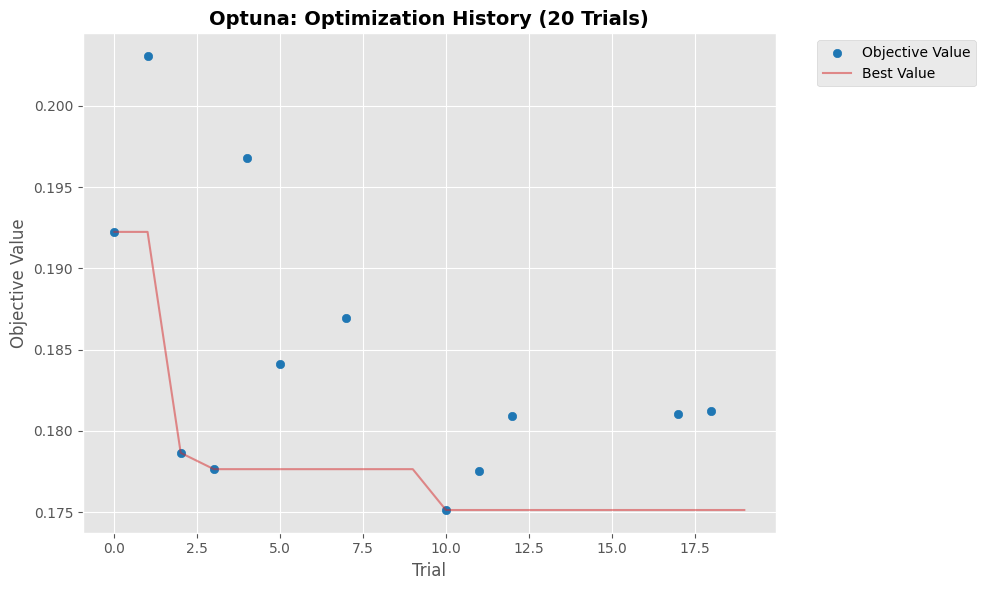

✓ optimization_history saved


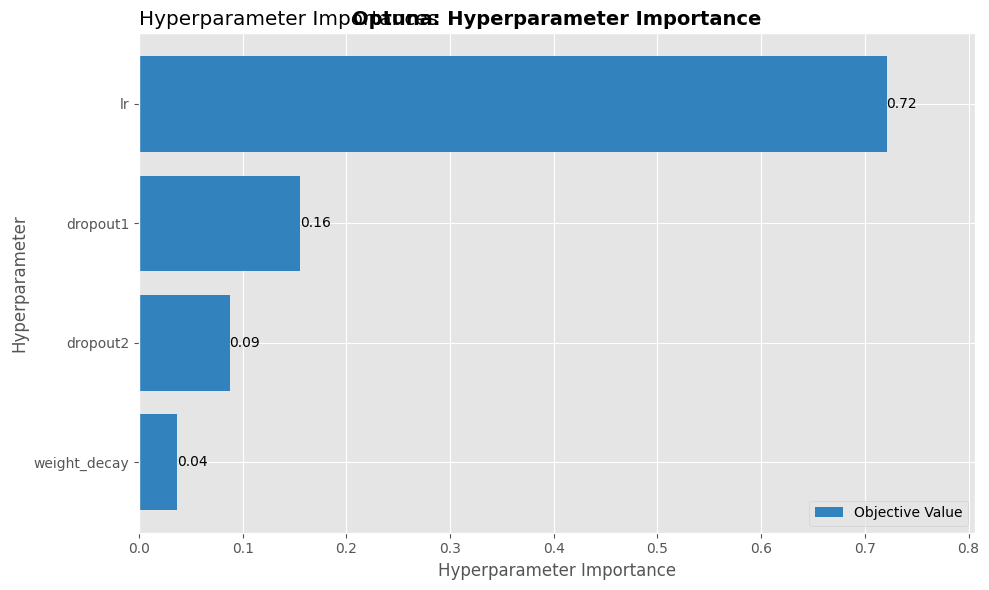

✓ param_importances saved


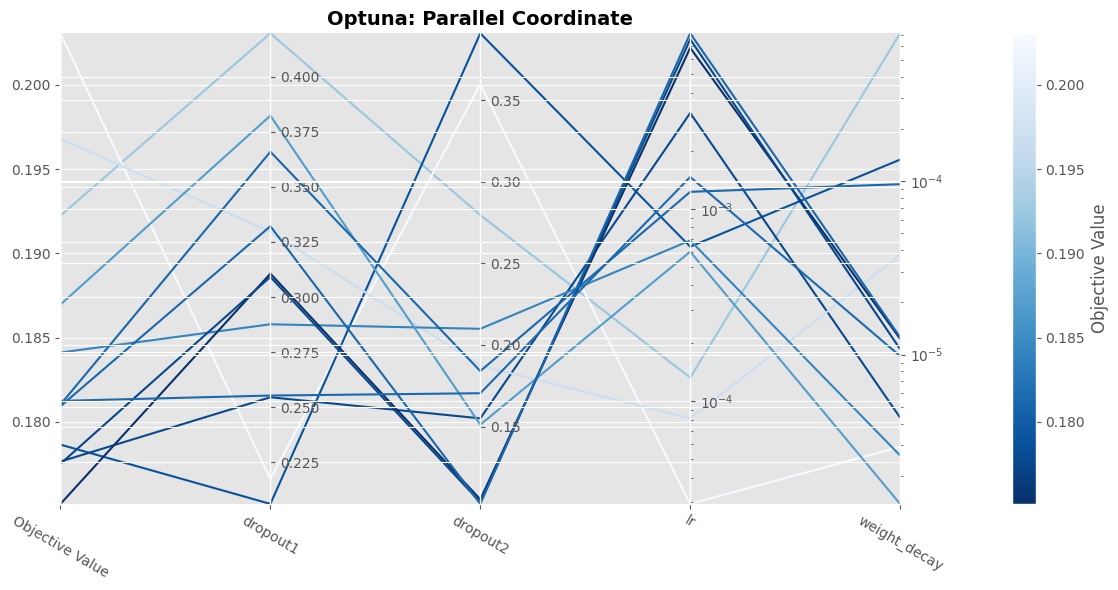

✓ parallel_coordinate saved

Default vs Best Hyperparameters:
   parameter  default     best  change
          lr   0.0010 0.006846 +584.6%
weight_decay   0.0001 0.000012  -87.7%
    dropout1   0.4000 0.310619  -22.3%
    dropout2   0.3000 0.105389  -64.9%

✓ Saved 20 trials to optuna_trials.csv
✓ Completed trials: 12/20


In [10]:
# --- Optuna Visualizations ---
# All plots use matplotlib backend for Kaggle compatibility (no kaleido needed)

def save_optuna_plot(ax_or_arr, filename, figsize=(10, 6)):
    """Save any Optuna matplotlib visualization to PNG."""
    ax = ax_or_arr if not isinstance(ax_or_arr, np.ndarray) else ax_or_arr.flat[0]
    fig = ax.figure
    fig.set_size_inches(*figsize)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT, filename), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

# 1. Optimization History
ax = plot_optimization_history(study)
ax.set_title("Optuna: Optimization History (20 Trials)", fontsize=14, fontweight='bold')
save_optuna_plot(ax, "optuna_optimization_history.png")
print("✓ optimization_history saved")

# 2. Parameter Importances (needs ≥2 completed trials)
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
if len(completed_trials) >= 2:
    try:
        ax = plot_param_importances(study)
        ax.set_title("Optuna: Hyperparameter Importance", fontsize=14, fontweight='bold')
        save_optuna_plot(ax, "optuna_param_importances.png")
        print("✓ param_importances saved")
    except ValueError as e:
        print(f"⚠ Cannot plot param_importances: {e}")
else:
    print(f"⚠ Need ≥2 completed trials for param_importances (have {len(completed_trials)})")

# 3. Parallel Coordinate
try:
    ax = plot_parallel_coordinate(study)
    ax.set_title("Optuna: Parallel Coordinate", fontsize=14, fontweight='bold')
    save_optuna_plot(ax, "optuna_parallel_coordinate.png", figsize=(12, 6))
    print("✓ parallel_coordinate saved")
except Exception as e:
    print(f"⚠ Cannot plot parallel_coordinate: {e}")

# 4. Default vs Best Hyperparameters Comparison
default_params = {'lr': 1e-3, 'weight_decay': 1e-4, 'dropout1': 0.4, 'dropout2': 0.3}
comparison_rows = []
for param_name in study.best_params:
    default_val = default_params.get(param_name, 'N/A')
    best_val = study.best_params[param_name]
    if isinstance(default_val, float) and default_val != 0:
        change_pct = ((best_val - default_val) / abs(default_val)) * 100
        change_str = f"{change_pct:+.1f}%"
    else:
        change_str = "—"
    comparison_rows.append({
        'parameter': param_name,
        'default': default_val,
        'best': best_val,
        'change': change_str
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(os.path.join(OUT, 'optuna_default_vs_best.csv'), index=False)
print("\nDefault vs Best Hyperparameters:")
print(comparison_df.to_string(index=False))

# 5. Trials DataFrame
trials_df = study.trials_dataframe()
trials_df.to_csv(os.path.join(OUT, 'optuna_trials.csv'), index=False)
print(f"\n✓ Saved {len(trials_df)} trials to optuna_trials.csv")
print(f"✓ Completed trials: {len(completed_trials)}/{len(study.trials)}")


## Training

Phase 1 (Epochs 1-8): Freeze backbone, train only the regression head
Phase 2 (Epochs 9-40): Unfreeze last 2 blocks of backbone + head
- Loss: MSELoss (regression)
- Optimizer: AdamW
- Scheduler: CosineAnnealingLR
- Early Stopping: patience=10 epochs
- Mixed Precision: torch.cuda.amp
- HPO: Optuna (20 trials) finds best lr, weight_decay, dropout1, dropout2 before full training

In [11]:
# --- Phase 1: Freeze backbone, train head only ---
import time

EPOCHS_PHASE1 = 8
EPOCHS_PHASE2 = 32
EPOCHS = EPOCHS_PHASE1 + EPOCHS_PHASE2  # 40 total

# Use best HPO params if available, otherwise defaults
if 'best_hpo_params' in dir() and best_hpo_params is not None:
    PHASE1_LR = best_hpo_params.get('lr', 1e-3)
    PHASE1_WD = best_hpo_params.get('weight_decay', 1e-4)
    DROPOUT1 = best_hpo_params.get('dropout1', 0.4)
    DROPOUT2 = best_hpo_params.get('dropout2', 0.3)
else:
    PHASE1_LR = 1e-3
    PHASE1_WD = 1e-4
    DROPOUT1 = 0.4
    DROPOUT2 = 0.3

print(f"Phase 1 params: lr={PHASE1_LR:.6f}, wd={PHASE1_WD:.6f}, dropout1={DROPOUT1:.3f}, dropout2={DROPOUT2:.3f}")

# Re-create model with HPO dropout params
model = BehavioralModel(dropout1=DROPOUT1, dropout2=DROPOUT2).to(DEVICE)
print(f"Model created with dropout1={DROPOUT1}, dropout2={DROPOUT2}")

# Freeze backbone
for param in model.backbone.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

criterion = nn.MSELoss()
optimizer_p1 = optim.AdamW(model.classifier.parameters(), lr=PHASE1_LR, weight_decay=PHASE1_WD)
scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=EPOCHS_PHASE1, eta_min=1e-7)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

train_log = []

print(f"Phase 1: Training head only ({EPOCHS_PHASE1} epochs)")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

for epoch in range(1, EPOCHS_PHASE1 + 1):
    epoch_start = time.time()
    model.train()
    running_loss = 0.0
    for images, targets, _ in tqdm(train_loader, desc=f"P1 Epoch {epoch}/{EPOCHS_PHASE1}"):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        
        optimizer_p1.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, targets)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer_p1)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
    
    train_loss = running_loss / len(train_subset)
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_mae_total = torch.zeros(6).to(DEVICE)
    with torch.no_grad():
        for images, targets, _ in val_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, targets)
            val_loss += loss.item() * images.size(0)
            val_mae_total += torch.abs(outputs - targets).sum(dim=0)
    
    val_loss /= len(val_subset)
    val_mae_per_trait = val_mae_total / len(val_subset)
    val_mae = val_mae_per_trait.mean().item()
    epoch_time = time.time() - epoch_start
    
    scheduler_p1.step()
    
    # Per-trait MAE logging
    trait_maes = {name: float(val_mae_per_trait[i]) for i, name in enumerate(SCORE_NAMES)}
    train_log.append({
        'epoch': epoch, 'phase': 1, 'train_loss': train_loss, 'val_loss': val_loss,
        'val_mae': val_mae, 'epoch_time': epoch_time, **trait_maes
    })
    print(f"P1 Epoch {epoch}/{EPOCHS_PHASE1} | loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_mae: {val_mae:.4f} | time: {epoch_time:.1f}s")


Phase 1 params: lr=0.006846, wd=0.000012, dropout1=0.311, dropout2=0.105
Model created with dropout1=0.3106186318163292, dropout2=0.10538856268444591
Phase 1: Training head only (8 epochs)
Trainable params: 329,478


P1 Epoch 1/8: 100%|██████████| 173/173 [01:03<00:00,  2.74it/s]


P1 Epoch 1/8 | loss: 0.0392 | val_loss: 0.0433 | val_mae: 0.1803 | time: 68.4s


P1 Epoch 2/8: 100%|██████████| 173/173 [00:34<00:00,  5.02it/s]


P1 Epoch 2/8 | loss: 0.0367 | val_loss: 0.0479 | val_mae: 0.1901 | time: 37.1s


...

P1 Epoch 6/8 | loss: 0.0334 | val_loss: 0.0473 | val_mae: 0.1878 | time: 36.6s


P1 Epoch 7/8: 100%|██████████| 173/173 [00:35<00:00,  4.93it/s]


P1 Epoch 7/8 | loss: 0.0332 | val_loss: 0.0463 | val_mae: 0.1838 | time: 37.8s


P1 Epoch 8/8: 100%|██████████| 173/173 [00:33<00:00,  5.13it/s]


P1 Epoch 8/8 | loss: 0.0325 | val_loss: 0.0480 | val_mae: 0.1869 | time: 36.3s


In [12]:
# --- Phase 2: Unfreeze last 2 blocks + head ---
print(f"\nBackbone blocks: {len(model.backbone.blocks)}")
print(f"Unfreezing last 2 blocks for fine-tuning...")

for param in model.backbone.blocks[-2:].parameters():
    param.requires_grad = True

# Use HPO-tuned or default learning rates
PHASE2_LR_BACKBONE = 3e-4
PHASE2_LR_HEAD = 1e-3
if 'best_hpo_params' in dir() and best_hpo_params is not None:
    PHASE2_WD = best_hpo_params.get('weight_decay', 1e-4)
else:
    PHASE2_WD = 1e-4

# Re-init optimizer with separate param groups
optimizer_p2 = optim.AdamW([
    {'params': model.backbone.blocks[-2:].parameters(), 'lr': PHASE2_LR_BACKBONE},
    {'params': model.classifier.parameters(), 'lr': PHASE2_LR_HEAD}
], weight_decay=PHASE2_WD)
scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=EPOCHS_PHASE2, eta_min=1e-7)

# Early stopping
best_val_mae = float('inf')
best_epoch = 0
patience_counter = 0
PATIENCE = 10
best_model_state = None

print(f"Phase 2: Fine-tuning last 2 blocks + head ({EPOCHS_PHASE2} epochs)")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Early stopping patience: {PATIENCE}")

for epoch in range(EPOCHS_PHASE1 + 1, EPOCHS + 1):
    epoch_start = time.time()
    model.train()
    running_loss = 0.0
    for images, targets, _ in tqdm(train_loader, desc=f"P2 Epoch {epoch}/{EPOCHS}"):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        
        optimizer_p2.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, targets)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer_p2)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
    
    train_loss = running_loss / len(train_subset)
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_mae_total = torch.zeros(6).to(DEVICE)
    with torch.no_grad():
        for images, targets, _ in val_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, targets)
            val_loss += loss.item() * images.size(0)
            val_mae_total += torch.abs(outputs - targets).sum(dim=0)
    
    val_loss /= len(val_subset)
    val_mae_per_trait = val_mae_total / len(val_subset)
    val_mae = val_mae_per_trait.mean().item()
    epoch_time = time.time() - epoch_start
    
    scheduler_p2.step()
    
    # Per-trait MAE logging
    trait_maes = {name: float(val_mae_per_trait[i]) for i, name in enumerate(SCORE_NAMES)}
    train_log.append({
        'epoch': epoch, 'phase': 2, 'train_loss': train_loss, 'val_loss': val_loss,
        'val_mae': val_mae, 'epoch_time': epoch_time, **trait_maes
    })
    print(f"P2 Epoch {epoch}/{EPOCHS} | loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_mae: {val_mae:.4f} | time: {epoch_time:.1f}s")
    
    # Early stopping check
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_epoch = epoch
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"  ✓ New best val_mae: {best_val_mae:.4f} at epoch {epoch}")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n early stopping at epoch {epoch}. Best val_mae: {best_val_mae:.4f} at epoch {best_epoch}")
            break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Restored best model from epoch {best_epoch} (val_mae: {best_val_mae:.4f})")

# Save training log
log_df = pd.DataFrame(train_log)
log_df.to_csv(os.path.join(OUT, 'training_log_A.csv'), index=False)
print(f"\nTraining log saved to {os.path.join(OUT, 'training_log_A.csv')}")
print(f"Best val_mae: {best_val_mae:.4f} at epoch {best_epoch}")
print(f"Total epochs trained: {train_log[-1]['epoch']}")



Backbone blocks: 7
Unfreezing last 2 blocks for fine-tuning...
Phase 2: Fine-tuning last 2 blocks + head (32 epochs)
Trainable params: 3,073,058
Early stopping patience: 10


P2 Epoch 9/40: 100%|██████████| 173/173 [01:02<00:00,  2.78it/s]


P2 Epoch 9/40 | loss: 0.0288 | val_loss: 0.0341 | val_mae: 0.1493 | time: 64.9s
  ✓ New best val_mae: 0.1493 at epoch 9


P2 Epoch 10/40: 100%|██████████| 173/173 [00:33<00:00,  5.15it/s]


P2 Epoch 10/40 | loss: 0.0226 | val_loss: 0.0280 | val_mae: 0.1305 | time: 36.2s
  ✓ New best val_mae: 0.1305 at epoch 10


...

P2 Epoch 38/40 | loss: 0.0033 | val_loss: 0.0155 | val_mae: 0.0714 | time: 37.1s


P2 Epoch 39/40: 100%|██████████| 173/173 [00:36<00:00,  4.73it/s]


P2 Epoch 39/40 | loss: 0.0034 | val_loss: 0.0152 | val_mae: 0.0697 | time: 39.4s
  ✓ New best val_mae: 0.0697 at epoch 39


P2 Epoch 40/40: 100%|██████████| 173/173 [00:34<00:00,  5.04it/s]


P2 Epoch 40/40 | loss: 0.0033 | val_loss: 0.0155 | val_mae: 0.0714 | time: 37.0s
Restored best model from epoch 39 (val_mae: 0.0697)

Training log saved to /kaggle/working/training_log_A.csv
Best val_mae: 0.0697 at epoch 39
Total epochs trained: 40


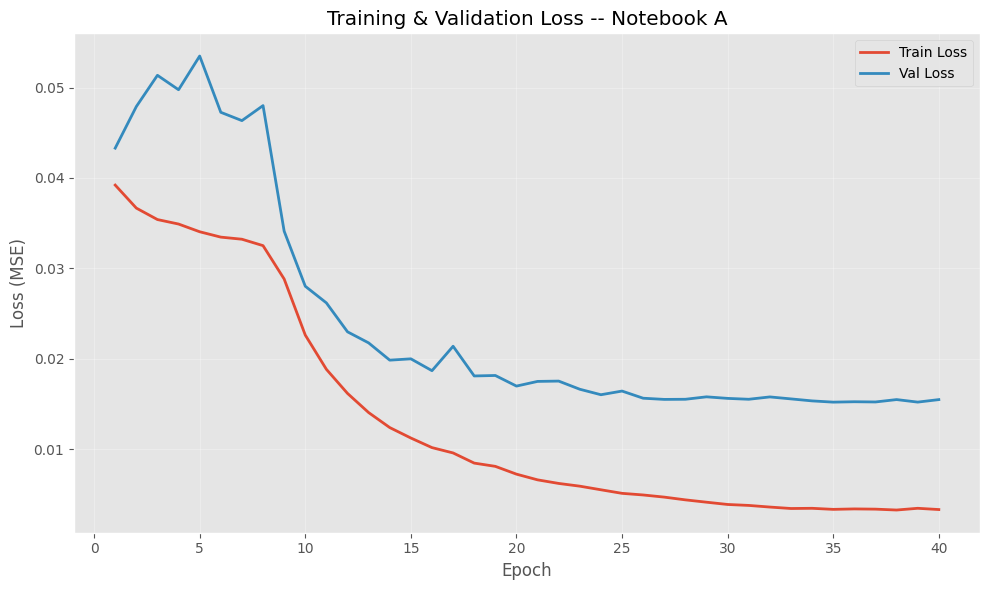

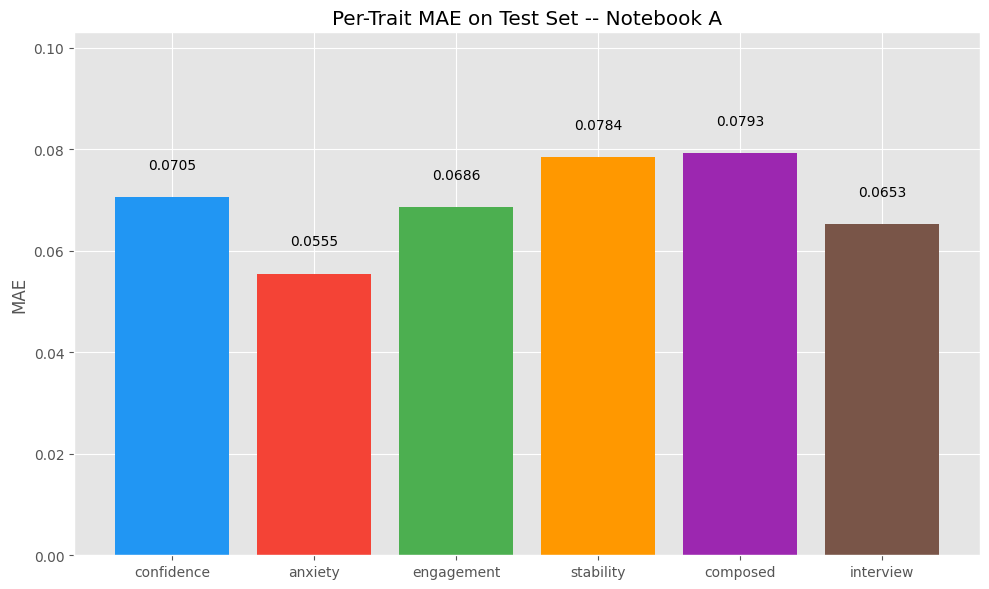

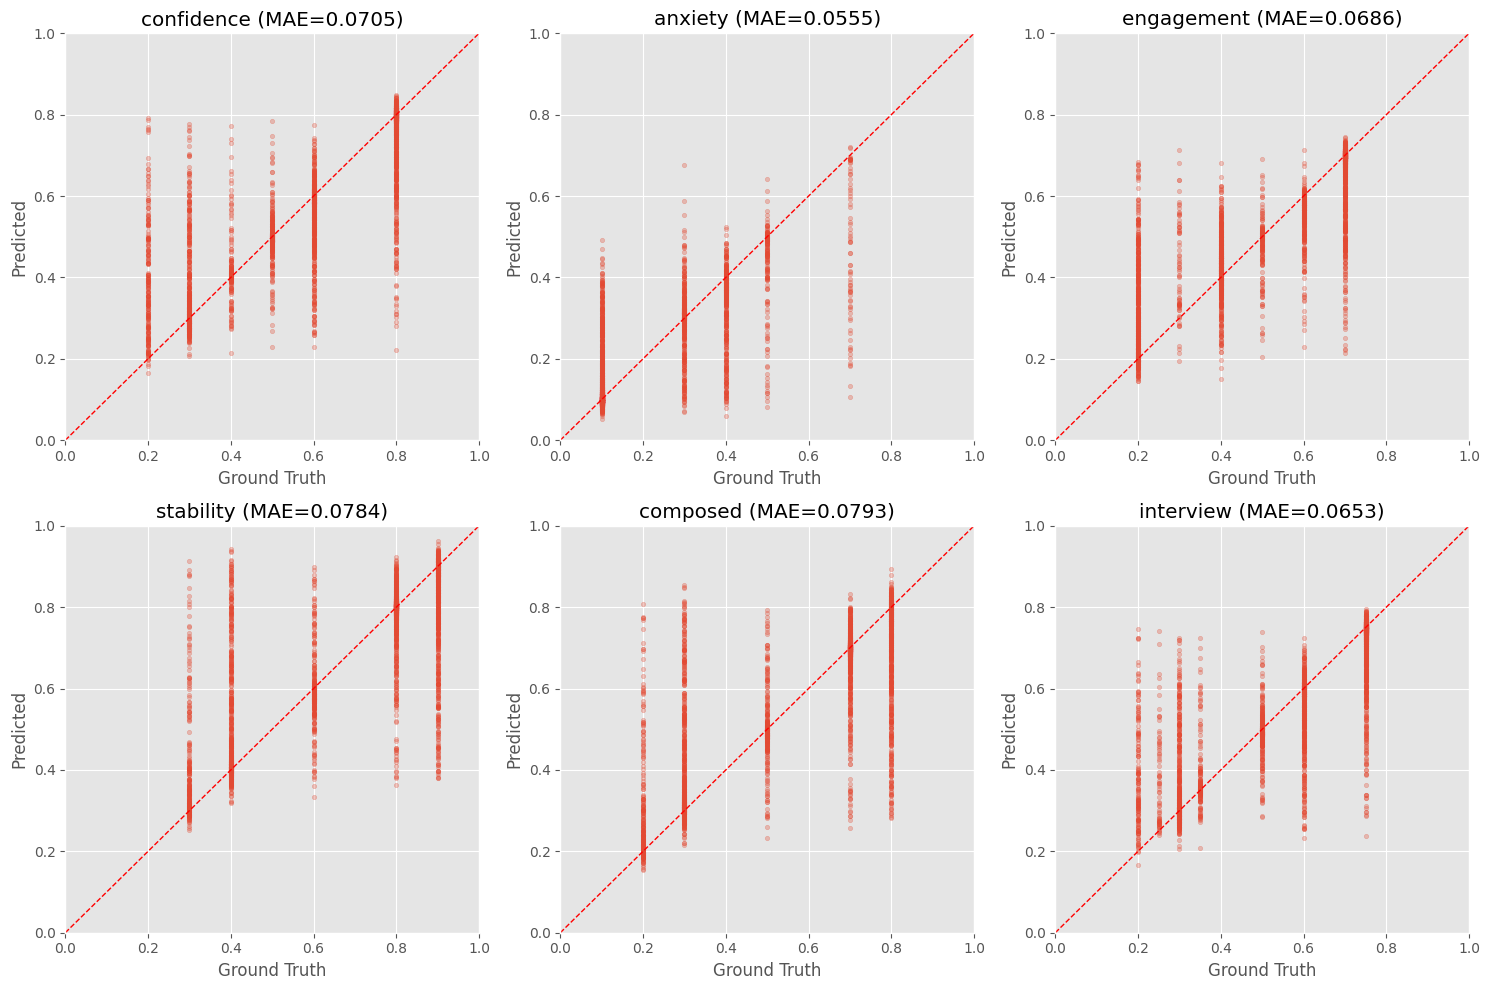

All plots saved.


In [13]:
# --- Generate Required Plots ---

# 1. Loss Curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(log_df['epoch'], log_df['train_loss'], label='Train Loss', linewidth=2)
ax.plot(log_df['epoch'], log_df['val_loss'], label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Training & Validation Loss -- Notebook A')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'loss_curve_A.png'), dpi=150, bbox_inches='tight')
plt.show()

# 2. MAE per Trait on Test Set
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for images, targets, _ in test_loader:
        images = images.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(images)
        all_preds.append(outputs.cpu())
        all_targets.append(targets)

all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)
per_trait_mae = torch.abs(all_preds - all_targets).mean(dim=0).numpy()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(SCORE_NAMES, per_trait_mae, color=['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#795548'])
ax.set_ylabel('MAE')
ax.set_title('Per-Trait MAE on Test Set -- Notebook A')
ax.set_ylim(0, max(per_trait_mae) * 1.3)
for bar, val in zip(bars, per_trait_mae):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, f'{val:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'mae_per_trait_A.png'), dpi=150, bbox_inches='tight')
plt.show()

# 3. Predictions vs Ground Truth (6 subplots)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, (name, ax) in enumerate(zip(SCORE_NAMES, axes.flatten())):
    ax.scatter(all_targets[:, i].numpy(), all_preds[:, i].numpy(), alpha=0.3, s=10)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1)
    ax.set_xlabel('Ground Truth')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name} (MAE={per_trait_mae[i]:.4f})')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'predictions_vs_ground_truth_A.png'), dpi=150, bbox_inches='tight')
plt.show()
print('All plots saved.')

In [14]:
# --- Save Model ---
model_path = os.path.join(OUT, 'model_final_A.pth')
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")
print(f"Model size: {os.path.getsize(model_path) / 1e6:.1f} MB")

# --- Save Config ---
config = {
    "backbone": "efficientnet_b0",
    "model_variant": "ra_in1k",
    "output_dim": 6,
    "dropout1": DROPOUT1 if 'DROPOUT1' in dir() else 0.4,
    "dropout2": DROPOUT2 if 'DROPOUT2' in dir() else 0.3,
    "hidden_dim": 256,
    "input_size": 224,
    "n_epochs": EPOCHS if 'EPOCHS' in dir() else 40,
    "batch_size": 64,
    "lr_head": PHASE1_LR if 'PHASE1_LR' in dir() else 1e-3,
    "lr_backbone": 3e-4,
    "scheduler": "CosineAnnealingLR",
    "early_stopping_patience": 10,
    "score_names": SCORE_NAMES
}
if 'best_hpo_params' in dir():
    config["best_hpo_params"] = best_hpo_params

with open(os.path.join(OUT, 'model_config_A.json'), 'w') as f:
    json.dump(config, f, indent=2)
print(f"Config saved to {os.path.join(OUT, 'model_config_A.json')}")

# --- Reconstruction Test ---
dropout1_val = DROPOUT1 if 'DROPOUT1' in dir() else 0.4
dropout2_val = DROPOUT2 if 'DROPOUT2' in dir() else 0.3
new_model = BehavioralModel(dropout1=dropout1_val, dropout2=dropout2_val)
new_model.load_state_dict(torch.load(model_path, map_location='cpu'))
new_model.eval()
test_input = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    test_output = new_model(test_input)
print(f"Reconstruction test: input={test_input.shape}, output={test_output.shape}")
print(f"Output range: [{test_output.min().item():.3f}, {test_output.max().item():.3f}]")
print("Reconstruction test PASSED!")


Model saved to /kaggle/working/model_final_A.pth
Model size: 17.7 MB
Config saved to /kaggle/working/model_config_A.json
Reconstruction test: input=torch.Size([1, 3, 224, 224]), output=torch.Size([1, 6])
Output range: [0.000, 1.000]
Reconstruction test PASSED!


In [15]:
# --- Inference Demo ---
model.eval()
demo_indices = random.sample(range(len(test_dataset)), 5)
demo_results = []

total_time = 0
for idx in demo_indices:
    image, target, class_idx = test_dataset[idx]
    image = image.unsqueeze(0).to(DEVICE)
    
    start_time = time.time()
    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            output = model(image)
    inference_time = (time.time() - start_time) * 1000  # ms
    total_time += inference_time
    
    scores = {name: float(output[0][i]) for i, name in enumerate(SCORE_NAMES)}
    tags = scores_to_behavioral_tags(scores)
    tags["ground_truth_class"] = int(class_idx)
    tags["ground_truth_scores"] = {name: float(target[i]) for i, name in enumerate(SCORE_NAMES)}
    demo_results.append(tags)
    
    print(f"\n--- Sample {idx} (Class {class_idx}) ---")
    print(f"Model outputs: {scores}")
    print(f"Behavioral tags: {json.dumps(tags, indent=2)}")

# Save demo results
with open(os.path.join(OUT, 'behavioral_tags_demo_A.json'), 'w') as f:
    json.dump(demo_results, f, indent=2)
print(f"\nDemo results saved to {os.path.join(OUT, 'behavioral_tags_demo_A.json')}")

# Model stats
avg_time = total_time / 5
model_size = os.path.getsize(model_path) / 1e6
print(f"\nModel size: {model_size:.1f} MB | Avg inference time per frame: {avg_time:.1f} ms")


--- Sample 2470 (Class 7) ---
Model outputs: {'confidence': 0.61083984375, 'anxiety': 0.093017578125, 'engagement': 0.424560546875, 'stability': 0.912109375, 'composed': 0.802734375, 'interview': 0.60888671875}
Behavioral tags: {
  "confidence_level": 0.611,
  "anxiety_signal": 0.093,
  "engagement_level": 0.425,
  "emotional_stability": 0.912,
  "dominant_emotion": "calm",
  "engagement_trend": "flat",
  "composed_ratio": 0.803,
  "behavioral_summary": "Candidate shows strong confidence.",
  "ground_truth_class": 7,
  "ground_truth_scores": {
    "confidence": 0.6000000238418579,
    "anxiety": 0.10000000149011612,
    "engagement": 0.4000000059604645,
    "stability": 0.8999999761581421,
    "composed": 0.800000011920929,
    "interview": 0.6000000238418579
  }
}

--- Sample 1374 (Class 4) ---
Model outputs: {'confidence': 0.75732421875, 'anxiety': 0.11474609375, 'engagement': 0.671875, 'stability': 0.7939453125, 'composed': 0.68359375, 'interview': 0.71533203125}
Behavioral tags: {

## Generalization Test: FER2013

Test the model on **FER2013** (Facial Expression Recognition 2013) to measure cross-dataset generalization.
FER2013 is a different distribution — 48×48 grayscale images from a competition dataset — so performance will be lower than on RAF-DB, but it shows how well the model transfers.

**Add FER2013 via Kaggle UI → Add Data → search `fer2013` by msambare.**

Class mapping (FER2013 → RAF-DB):
angry→6, disgust→3, fear→2, happy→4, sad→5, surprise→1, neutral→7

FER2013 test directory: /kaggle/input/datasets/msambare/fer2013/test
Loaded 7178 images from /kaggle/input/datasets/msambare/fer2013/test
FER2013 test samples: 7178


FER2013 inference: 100%|██████████| 113/113 [01:08<00:00,  1.65it/s]



=== FER2013 Generalization Results ===
Overall MAE: 0.1483
  confidence: 0.1413
  anxiety: 0.1519
  engagement: 0.1238
  stability: 0.1733
  composed: 0.1726
  interview: 0.1269

Per-class MAE on FER2013:
  Surprise: MAE=0.0729 (n=831)
  Fear: MAE=0.2570 (n=1024)
  Disgust: MAE=0.1198 (n=111)
  Happy: MAE=0.1065 (n=1774)
  Sad: MAE=0.1751 (n=1247)
  Angry: MAE=0.1506 (n=958)
  Neutral: MAE=0.1426 (n=1233)


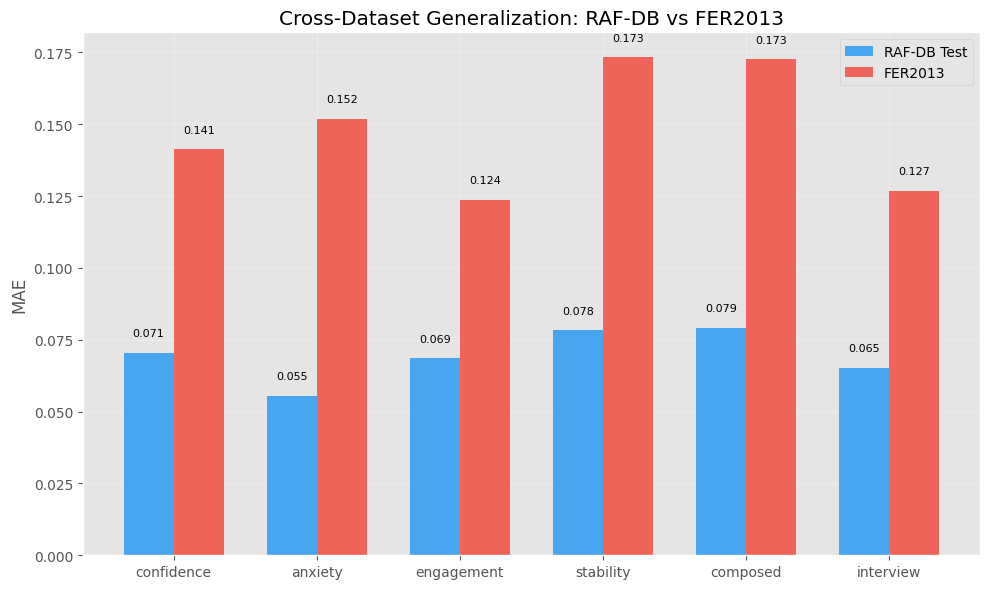

Generalization comparison plot saved.
Saved generalization results to /kaggle/working/generalization_results.json


In [16]:
fer_test_dir = None
for candidate in [
    '/kaggle/input/fer2013/test',
    '/kaggle/input/datasets/msambare/fer2013/test',
]:
    if os.path.isdir(candidate):
        fer_test_dir = candidate
        break

# Fallback: search for fer2013 test folder
if fer_test_dir is None:
    for root, dirs, _ in os.walk('/kaggle/input/'):
        if 'angry' in dirs and 'happy' in dirs and 'sad' in dirs:
            # Check parent is 'test' or similar
            if 'train' in os.listdir(os.path.dirname(root)) or root.endswith('test'):
                fer_test_dir = root
                break

if fer_test_dir is None:
    print('FER2013 dataset not found. Add it via Kaggle UI -> Add Data -> search fer2013 by msambare.')
    print('Skipping generalization test.')
else:
    print(f'FER2013 test directory: {fer_test_dir}')
    fer_dataset = RAFDBDataset(fer_test_dir, transform=val_transforms, noise_std=0.0)
    fer_loader = DataLoader(fer_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
    print(f'FER2013 test samples: {len(fer_dataset)}')
    
    # Run inference
    model.eval()
    fer_preds = []
    fer_targets = []
    fer_class_indices = []
    with torch.no_grad():
        for images, targets, class_indices in tqdm(fer_loader, desc='FER2013 inference'):
            images = images.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = model(images)
            fer_preds.append(outputs.cpu())
            fer_targets.append(targets)
            fer_class_indices.extend(class_indices.tolist())
    
    fer_preds = torch.cat(fer_preds, dim=0)
    fer_targets = torch.cat(fer_targets, dim=0)
    fer_mae = torch.abs(fer_preds - fer_targets).mean(dim=0).numpy()
    fer_mae_mean = fer_mae.mean()
    
    # Class-wise accuracy (which emotion class predicts best)
    fer_pred_classes = fer_preds.argmax(dim=1).numpy()
    fer_true_classes = np.array(fer_class_indices)
    
    # Emotion names for display
    EMOTION_NAMES = {1: 'Surprise', 2: 'Fear', 3: 'Disgust', 4: 'Happy', 5: 'Sad', 6: 'Angry', 7: 'Neutral'}
    
    print(f'\n=== FER2013 Generalization Results ===')
    print(f'Overall MAE: {fer_mae_mean:.4f}')
    for i, name in enumerate(SCORE_NAMES):
        print(f'  {name}: {fer_mae[i]:.4f}')
    
    # Per-class sample counts and MAE
    print(f'\nPer-class MAE on FER2013:')
    for cls_idx in sorted(set(fer_true_classes)):
        mask = fer_true_classes == cls_idx
        cls_mae = torch.abs(fer_preds[mask] - fer_targets[mask]).mean().item()
        cls_count = mask.sum()
        print(f'  {EMOTION_NAMES.get(cls_idx, f"Class {cls_idx}")}: MAE={cls_mae:.4f} (n={cls_count})')
    
    # Comparison plot: RAF-DB test vs FER2013
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(SCORE_NAMES))
    width = 0.35
    # Get RAF-DB test MAE for comparison
    raf_mae = per_trait_mae  # from earlier evaluation
    ax.bar(x - width/2, raf_mae, width, label='RAF-DB Test', color='#2196F3', alpha=0.8)
    ax.bar(x + width/2, fer_mae, width, label='FER2013', color='#F44336', alpha=0.8)
    ax.set_ylabel('MAE')
    ax.set_title('Cross-Dataset Generalization: RAF-DB vs FER2013')
    ax.set_xticks(x)
    ax.set_xticklabels(SCORE_NAMES)
    ax.legend()
    ax.grid(True, alpha=0.3)
    for i, (r, f) in enumerate(zip(raf_mae, fer_mae)):
        ax.text(i - width/2, r + 0.005, f'{r:.3f}', ha='center', va='bottom', fontsize=8)
        ax.text(i + width/2, f + 0.005, f'{f:.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'generalization_rafdb_vs_fer2013.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Generalization comparison plot saved.')
    
    # Save generalization results
    gen_results = {
        'rafdb_test_mae': {name: float(raf_mae[i]) for i, name in enumerate(SCORE_NAMES)},
        'rafdb_test_mae_mean': float(raf_mae.mean()),
        'fer2013_mae': {name: float(fer_mae[i]) for i, name in enumerate(SCORE_NAMES)},
        'fer2013_mae_mean': float(fer_mae_mean),
    }
    with open(os.path.join(OUT, 'generalization_results.json'), 'w') as f:
        json.dump(gen_results, f, indent=2)
    print(f'Saved generalization results to {os.path.join(OUT, "generalization_results.json")}')